# 05 — Field profile validation: 1+1D vs 3+1D

Compares the scalar field φ(z, t) directly between the BubbleMaster 1+1D simulation
and a sledgehamr 3+1D run at exactly the same time.

**Workflow**
1. Run **Section 1** to discover available sledgehamr field snapshot times.
2. Pick the snapshot index(es) you want to compare (`SNAPSHOT_INDICES`).
3. Run **Section 2** to write BubbleMaster setup files and SLURM scripts (one per snapshot time).
4. Submit: `! sbatch scripts/fields_<tag>_t<i>.sh`
5. After jobs complete, run **Sections 3–4** to load and plot.

In [1]:
import sys
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

import ptbuilder as pt
from ptbuilder.ic import _two_bubble_ic, _cutoff_times, BubbleMasterParams

REPO_ROOT = Path(pt.__file__).parent.parent

PYSLEDGEHAMR_PATH = '/global/cfs/cdirs/m3166/buschman/sledgehamr'
sys.path.append(PYSLEDGEHAMR_PATH)
import pySledgehamr as sledgehamr

config = pt.Config()
params = BubbleMasterParams(dz=0.005, n_w=64, n_k=51,
                             how_often_ds=5, baby_steps=100, cutoff_type=0)

# -----------------------------------------------------------------------
# Validation point to compare.  Pick one pair (lambda_bar, d, sh_path).
# -----------------------------------------------------------------------
# Bubble locations in sledgehamr reference lambda_bar=0.84
xlocs = [7.225e+1, 1.278e+2, 1.087e+2]
ylocs = [8.992e+1, 8.992e+1, 1.101e+2]
zlocs = [1.000e+2, 1.000e+2, 1.000e+2]
pos = np.column_stack((xlocs, ylocs, zlocs))
distances = np.linalg.norm(pos[:, None, :] - pos[None, :, :], axis=-1)
distances = np.unique(distances)
print(distances)

LAMBDA_BAR = 0.84
SH_PATH    = '/pscratch/sd/b/buschman/other_runs/bubble_N3_234_0_1_/'
D = distances[3]
SH_L       = 200.
N0 = 2048

[ 0.         27.78565097 41.663352   55.55      ]


In [2]:
output = sledgehamr.Output(SH_PATH)

Number of slices found: 76
Number of coarse boxes found: 0
Number of full boxes found: 0
Number of projections found: 8
Number of spectra found: 0
Number of gravitational wave spectra found: 38
Number of slices of truncation errors found: 0
Number of coarse boxes of truncation errors found: 0
Number of full boxes of truncation errors found: 0


t = 40.283203125


(0.0, 75.0)

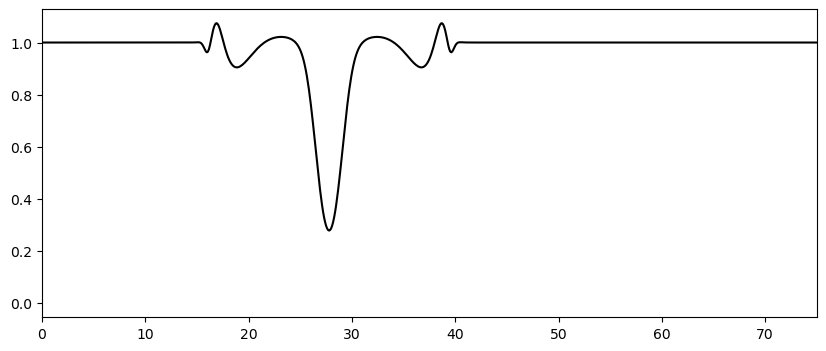

In [14]:
i = 40
lev = 0
slices = output.GetSlice(i, 'x', lev, ['Phi'])
field = slices['Phi'][N0*2**lev//2,:]
print('t =', slices['t'])
axis = np.linspace(0, SH_L, N0*2**lev)
axis -= xlocs[0]
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(axis, field, marker='', color='black')
plt.xlim(0, 75)

t = 40.283203125 (2048, 2048)


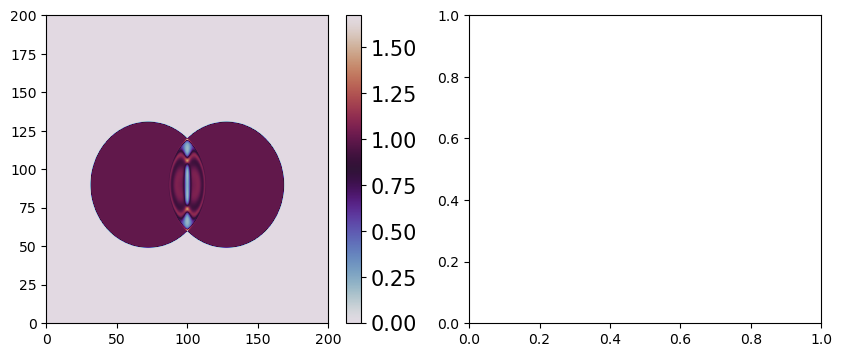

In [13]:
#### id of slice to be plotted
i = 40
for lev in [0]:
    # Load data of slice
    slices = output.GetSlice(i, 'x', lev, ['Phi'])
    field = slices['Phi']
    print('t =',slices['t'], np.shape(field))
    fig, ax = plt.subplots(figsize=(10,4), ncols=2)
    axis = np.linspace(0,SH_L,np.shape(field)[0])
    im = ax[0].pcolormesh(axis, axis, field, cmap='twilight')
    cb = fig.colorbar(im, ax=ax[0])
    cb.ax.tick_params(labelsize=15)

## 1. Discover sledgehamr field snapshot times

## 2. Write BubbleMaster setup and SLURM scripts

One setup file per snapshot time — `times = [t_snap]` so the job runs the field
evolution to exactly that time and saves `fields.h5` with `--save-fields`.

In [5]:
scripts_dir = REPO_ROOT / 'scripts'
logs_dir    = REPO_ROOT / 'logs'
scripts_dir.mkdir(exist_ok=True)
logs_dir.mkdir(exist_ok=True)

t_snap = 70.5
model = pt.PhysicsModel(pt.Phi4Potential(LAMBDA_BAR), config)
gamma = float(model.kinematics.Gamma(model.kinematics.collision_time(D)))
tag   = f'lb{LAMBDA_BAR}_g{gamma:.4g}'

#for snap in snap_chosen:
    #t_snap = snap['t']
    #i_snap = snap['index']
if True:
    run_tag = f'{tag}'

    run_dir    = model.results_dir / 'field_validation' / run_tag
    setup_path = run_dir / 'setup.h5'
    out_dir    = run_dir / 'out'
    run_dir.mkdir(parents=True, exist_ok=True)

    # Single time point — runs the evolution and saves fields at exactly t_snap.
    # The GW integral at this one time is unused; we only need fields.h5.
    times = np.array([t_snap])
    pt.write_2d_setup(model, gamma=gamma, times=times,
                      path=setup_path, params=params)

    script_path = scripts_dir / f'fields_{run_tag}.sh'
    slurm = f"""#!/bin/bash
#SBATCH --constraint=cpu
#SBATCH --nodes=1
#SBATCH --tasks-per-node=1
#SBATCH --cpus-per-task=128
#SBATCH --qos=premium
#SBATCH --time=01:00:00
#SBATCH --job-name=bm_fields_{run_tag}
#SBATCH --output={logs_dir}/bm_fields_{run_tag}_%j.out

export OMP_NUM_THREADS=128
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

mkdir -p {out_dir}
/usr/bin/time --verbose srun {config.bubblemaster_bin} {setup_path} {out_dir}/ --save-fields
"""
    script_path.write_text(slurm)
    print(f'[{run_tag}]  t_snap={t_snap:.4f}  setup → {setup_path}')
    print(f'             script → {script_path}')

print('\nSubmit with:  sbatch scripts/fields_<tag>.sh')

[lb0.84_g3.974]  t_snap=70.5000  setup → /global/cfs/cdirs/m3166/buschman/PhaseTransitionBuilder/data/phi4_lambda_bar0.84/field_validation/lb0.84_g3.974/setup.h5
             script → /global/cfs/cdirs/m3166/buschman/PhaseTransitionBuilder/scripts/fields_lb0.84_g3.974.sh

Submit with:  sbatch scripts/fields_<tag>.sh


## 3. Load 1+1D BubbleMaster field and extract φ(z, t)

In [6]:
def load_bm_fields(out_dir):
    """
    Load fields.h5 saved by bubblemaster --save-fields.
    Returns (s, z, phi) where phi[i_s, i_z] is the Milne-coordinate field.
    """
    with h5py.File(Path(out_dir) / 'fields.h5', 'r') as f:
        s   = f['s'][:]
        z   = f['z'][:]
        phi = f['phi'][:]    # shape (n_s, n_z)
    return s, z, phi


def extract_phi_at_t(s_bm, z_bm, phi_bm, t):
    """
    Extract the 1+1D field along z at Minkowski time t.

    BubbleMaster evolves in Milne coordinates (s, z) where s = sqrt(t^2 - z^2).
    For each z, the corresponding s at time t is sqrt(t^2 - z^2).
    Points with |z| >= t are outside the forward light cone of the collision
    and are not part of the Milne grid — return NaN there.
    """
    interp = RegularGridInterpolator(
        (s_bm, z_bm), phi_bm,
        method='linear', bounds_error=False, fill_value=np.nan
    )

    s_at_t = np.where(np.abs(z_bm) < t, np.sqrt(np.maximum(t**2 - z_bm**2, 0.)), np.nan)
    pts    = np.column_stack([s_at_t, z_bm])
    phi_t  = interp(pts)
    return z_bm, phi_t


# Load fields for each snapshot
bm_fields = {}
for snap in snap_chosen:
    i_snap  = snap['index']
    t_snap  = snap['t']
    run_tag = f'{tag}_t{i_snap}'
    out_dir = model.results_dir / 'field_validation' / run_tag / 'out'

    try:
        s_bm, z_bm, phi_bm = load_bm_fields(out_dir)
        z_t, phi_t = extract_phi_at_t(s_bm, z_bm, phi_bm, t_snap)
        bm_fields[i_snap] = dict(s=s_bm, z=z_bm, phi=phi_bm,
                                  z_t=z_t, phi_t=phi_t, t=t_snap)
        print(f'[t{i_snap}]  t={t_snap:.4f}  s grid: [{s_bm[0]:.3f}, {s_bm[-1]:.3f}]  '
              f'z grid: [{z_bm[0]:.3f}, {z_bm[-1]:.3f}]')
    except FileNotFoundError:
        print(f'[t{i_snap}]  fields.h5 not found — submit and rerun job')

NameError: name 'snap_chosen' is not defined

## 4. Compare 1+1D vs 3+1D field profiles

In [ ]:
colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']

fig, axes = plt.subplots(1, len(snap_chosen),
                          figsize=(6 * len(snap_chosen), 5),
                          sharey=True)
if len(snap_chosen) == 1:
    axes = [axes]

for ax, snap, color in zip(axes, snap_chosen, colors):
    i_snap = snap['index']
    t_snap = snap['t']

    # 1+1D
    if i_snap in bm_fields:
        bf = bm_fields[i_snap]
        ax.plot(bf['z_t'], bf['phi_t'],
                color=color, lw=2, linestyle=':', label='1+1D')

    # 3+1D  (USER: fill in)
    try:
        z_sh, phi_sh = get_sh_field(SH_PATH, i_snap)
        ax.plot(z_sh, phi_sh,
                color=color, lw=2, linestyle='-', label='3+1D')
    except NotImplementedError:
        ax.text(0.5, 0.5, 'sledgehamr\nfield loader\nnot yet filled in',
                ha='center', va='center', transform=ax.transAxes, fontsize=9)

    ax.set_title(f't = {t_snap:.3f}')
    ax.set_xlabel('z')
    ax.legend(frameon=False)

axes[0].set_ylabel(r'$\phi$')
fig.suptitle(rf'$\lambda_{{\rm bar}}={LAMBDA_BAR}$,  $\gamma={gamma:.4g}$,  $d={D:.3f}$', y=1.01)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'validate_fields.pdf', bbox_inches='tight')
plt.show()

## Appendix: 2D Milne field (s, z)

In [ ]:
# Quick 2D view of the full Milne-coordinate field for one snapshot
i_plot = SNAPSHOT_INDICES[0]
if i_plot in bm_fields:
    bf = bm_fields[i_plot]
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.pcolormesh(bf['z'], bf['s'], bf['phi'], shading='auto', cmap='RdBu_r')
    plt.colorbar(im, ax=ax, label=r'$\phi$')

    # Overlay the t = t_snap hypersurface
    t_snap = bf['t']
    z_lc   = bf['z'][bf['z'] < t_snap]
    ax.plot(z_lc, np.sqrt(t_snap**2 - z_lc**2),
            'k--', lw=1.5, label=f't = {t_snap:.3f}')

    ax.set_xlabel('z  (Milne)')
    ax.set_ylabel('s  (Milne proper time)')
    ax.set_title('BubbleMaster field in Milne coordinates')
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()